[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


✅ Corpus loaded successfully

📊 DATASET STATISTICS
Total Documents: 1
Total Tokens: 17672
Vocabulary Size: 2190

🔥 Top 20 Frequent Words:
lectures: 436
data: 272
learning: 259
course: 224
computer: 196
algorithms: 168
design: 163
systems: 150
engineering: 135
science: 135
introduction: 131
edition: 108
students: 106
level: 105
tech: 102
elective: 97
networks: 97
applications: 96
courses: 91
department: 90


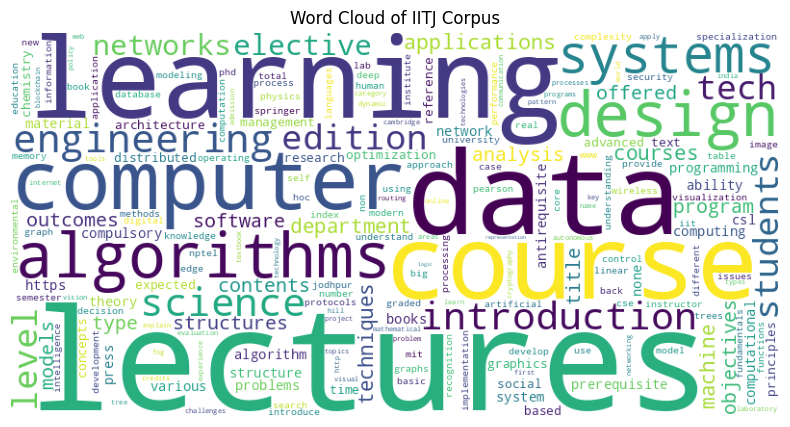


✅ Clean corpus saved as clean_corpus.txt


In [25]:
# ============================================================
# TASK-1: DATASET PREPARATION (FROM CORPUS FILE)
# ============================================================

# Install if needed
# !pip install nltk wordcloud matplotlib

import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to address LookupError for punkt_tab

# ------------------------------------------------------------
# 1. LOAD CORPUS FILE
# ------------------------------------------------------------

file_path = "/content/corpus.txt"   # <-- your file

with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

print("✅ Corpus loaded successfully")

# ------------------------------------------------------------
# 2. PREPROCESSING (LIGHT CLEANING ONLY)
# ------------------------------------------------------------

def preprocess(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()

    tokens = word_tokenize(text)

    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]

    tokens = [w for w in tokens if len(w) > 2]

    return tokens

tokens = preprocess(raw_text)

# ------------------------------------------------------------
# 3. DATASET STATISTICS
# ------------------------------------------------------------

num_docs = 1   # since single corpus file
num_tokens = len(tokens)
vocab = set(tokens)
vocab_size = len(vocab)

print("\n📊 DATASET STATISTICS")
print(f"Total Documents: {num_docs}")
print(f"Total Tokens: {num_tokens}")
print(f"Vocabulary Size: {vocab_size}")

# ------------------------------------------------------------
# 4. WORD FREQUENCY
# ------------------------------------------------------------

word_freq = Counter(tokens)

print("\n🔥 Top 20 Frequent Words:")
for word, freq in word_freq.most_common(20):
    print(f"{word}: {freq}")

# ------------------------------------------------------------
# 5. WORD CLOUD
# ------------------------------------------------------------

if word_freq:
    wordcloud = WordCloud(width=800, height=400, background_color='white')\
        .generate_from_frequencies(word_freq)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title("Word Cloud of IITJ Corpus")
    plt.show()
else:
    print("No words available for WordCloud")

# ------------------------------------------------------------
# 6. SAVE CLEAN TOKENS (FOR TASK-2)
# ------------------------------------------------------------

clean_text = " ".join(tokens)

with open("clean_corpus.txt", "w", encoding="utf-8") as f:
    f.write(clean_text)

print("\n✅ Clean corpus saved as clean_corpus.txt")

In [26]:
import numpy as np
import random
from collections import Counter
import matplotlib.pyplot as plt

In [27]:
# Build vocabulary
vocab = list(set(tokens))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
vocab_size = len(vocab)

# Convert tokens → indices
data = [word2idx[w] for w in tokens if w in word2idx]

In [28]:
def generate_skipgram_data(data, window_size):
    pairs = []
    for i, target in enumerate(data):
        context_range = range(max(0, i-window_size), min(len(data), i+window_size+1))
        for j in context_range:
            if i != j:
                pairs.append((target, data[j]))
    return pairs

In [29]:
def generate_cbow_data(data, window_size):
    pairs = []
    for i in range(window_size, len(data)-window_size):
        context = data[i-window_size:i] + data[i+1:i+window_size+1]
        target = data[i]
        pairs.append((context, target))
    return pairs

In [30]:
def get_negative_samples(target, vocab_size, k):
    negatives = []
    while len(negatives) < k:
        neg = random.randint(0, vocab_size-1)
        if neg != target:
            negatives.append(neg)
    return negatives

In [31]:
def init_embeddings(vocab_size, dim):
    W_in = np.random.randn(vocab_size, dim) * 0.01
    W_out = np.random.randn(vocab_size, dim) * 0.01
    return W_in, W_out

In [32]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [33]:
def train_skipgram(pairs, vocab_size, dim, neg_samples, lr=0.01, epochs=1):
    W_in, W_out = init_embeddings(vocab_size, dim)
    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for target, context in pairs:
            v = W_in[target]

            # Positive sample
            score = sigmoid(np.dot(v, W_out[context]))
            loss = -np.log(score + 1e-9)

            grad = score - 1
            W_out[context] -= lr * grad * v
            W_in[target] -= lr * grad * W_out[context]

            total_loss += loss

            # Negative samples
            negatives = get_negative_samples(context, vocab_size, neg_samples)

            for neg in negatives:
                score = sigmoid(np.dot(v, W_out[neg]))
                loss = -np.log(1 - score + 1e-9)

                grad = score
                W_out[neg] -= lr * grad * v
                W_in[target] -= lr * grad * W_out[neg]

                total_loss += loss

        losses.append(total_loss)

    return W_in, losses

In [34]:
def train_cbow(pairs, vocab_size, dim, neg_samples, lr=0.01, epochs=1):
    W_in, W_out = init_embeddings(vocab_size, dim)
    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for context, target in pairs:
            v = np.mean(W_in[context], axis=0)

            # Positive
            score = sigmoid(np.dot(v, W_out[target]))
            loss = -np.log(score + 1e-9)

            grad = score - 1
            W_out[target] -= lr * grad * v

            for w in context:
                W_in[w] -= lr * grad * W_out[target]

            total_loss += loss

            # Negative
            negatives = get_negative_samples(target, vocab_size, neg_samples)

            for neg in negatives:
                score = sigmoid(np.dot(v, W_out[neg]))
                loss = -np.log(1 - score + 1e-9)

                grad = score
                W_out[neg] -= lr * grad * v

                for w in context:
                    W_in[w] -= lr * grad * W_out[neg]

                total_loss += loss

        losses.append(total_loss)

    return W_in, losses

In [35]:
dimensions = [50, 100, 200]
windows = [3, 5]
neg_samples_list = [5, 10]

results = []

# We will store the last trained model's weights to use in the analysis cells
W_in = None

for dim in dimensions:
    for win in windows:
        for neg in neg_samples_list:

            sg_pairs = generate_skipgram_data(data, win)
            cbow_pairs = generate_cbow_data(data, win)

            # Capture W_in from the training functions
            W_in_sg, sg_loss = train_skipgram(sg_pairs, vocab_size, dim, neg)
            W_in_cbow, cbow_loss = train_cbow(cbow_pairs, vocab_size, dim, neg)

            results.append(("Skip-gram", dim, win, neg, sg_loss[-1]))
            results.append(("CBOW", dim, win, neg, cbow_loss[-1]))

            # For demonstration, we'll keep the Skip-gram weights from the last iteration
            W_in = W_in_sg

        Model  Dim  Window  Negative          Loss
0   Skip-gram   50       3         5  4.407864e+05
1        CBOW   50       3         5  7.346916e+04
2   Skip-gram   50       3        10  7.699913e+05
3        CBOW   50       3        10  1.346835e+05
4   Skip-gram   50       5         5  7.240887e+05
5        CBOW   50       5         5  7.345193e+04
6   Skip-gram   50       5        10  1.047713e+06
7        CBOW   50       5        10  1.346082e+05
8   Skip-gram  100       3         5  4.406765e+05
9        CBOW  100       3         5  7.346830e+04
10  Skip-gram  100       3        10  7.673048e+05
11       CBOW  100       3        10  1.346726e+05
12  Skip-gram  100       5         5  7.206949e+05
13       CBOW  100       5         5  7.345015e+04
14  Skip-gram  100       5        10  1.027267e+06
15       CBOW  100       5        10  1.345180e+05
16  Skip-gram  200       3         5  4.404104e+05
17       CBOW  200       3         5  7.346409e+04
18  Skip-gram  200       3     

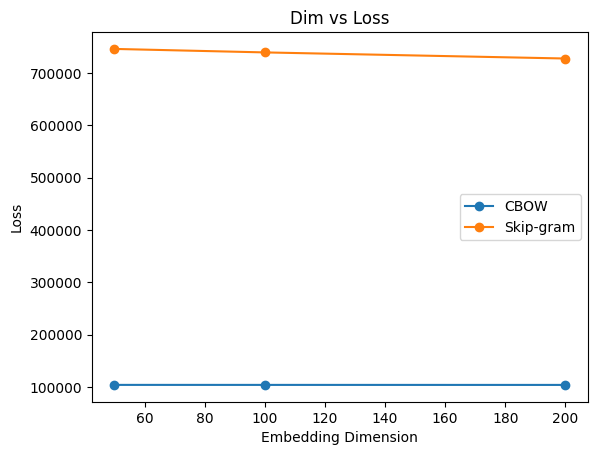

In [36]:
import pandas as pd

df = pd.DataFrame(results, columns=["Model", "Dim", "Window", "Negative", "Loss"])

print(df)

# Dimension vs Loss
plt.figure()
for model in ["CBOW", "Skip-gram"]:
    subset = df[df["Model"] == model]
    grouped = subset.groupby("Dim")["Loss"].mean()
    plt.plot(grouped.index, grouped.values, marker='o', label=model)

plt.xlabel("Embedding Dimension")
plt.ylabel("Loss")
plt.title("Dim vs Loss")
plt.legend()
plt.show()

In [37]:
import numpy as np

def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2) + 1e-9)

In [38]:
def get_top_k_similar(word, W, word2idx, idx2word, k=5):
    if word not in word2idx:
        return []

    idx = word2idx[word]
    target_vec = W[idx]

    similarities = []

    for i in range(len(W)):
        if i == idx:
            continue
        sim = cosine_similarity(target_vec, W[i])
        similarities.append((idx2word[i], sim))

    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:k]

In [39]:
words_to_check = ["research", "student", "phd", "exam"]

for word in words_to_check:
    print(f"\n✄ Top 5 for '{word}':")
    neighbors = get_top_k_similar(word, W_in, word2idx, idx2word)

    for w, score in neighbors:
        print(f"{w} ({score:.4f})")


✄ Top 5 for 'research':
machine (0.9971)
various (0.9970)
structures (0.9970)
optimization (0.9970)
number (0.9969)

✄ Top 5 for 'student':
pattern (0.9732)
issues (0.9730)
distributed (0.9728)
publishers (0.9728)
recognition (0.9727)

✄ Top 5 for 'phd':
type (0.9980)
structure (0.9979)
tech (0.9979)
elective (0.9978)
csl (0.9977)

✄ Top 5 for 'exam':


In [40]:
def analogy(a, b, c, W, word2idx, idx2word, k=5):
    if a not in word2idx or b not in word2idx or c not in word2idx:
        return []

    vec = W[word2idx[b]] - W[word2idx[a]] + W[word2idx[c]]

    similarities = []

    for i in range(len(W)):
        word = idx2word[i]
        if word in [a, b, c]:
            continue

        sim = cosine_similarity(vec, W[i])
        similarities.append((word, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:k]

In [41]:
print("\n✅ Analogy Results:\n")

# 1
print("UG : BTech :: PG : ?")
print(analogy("ug", "btech", "pg", W_in, word2idx, idx2word))

# 2
print("\nstudent : exam :: researcher : ?")
print(analogy("student", "exam", "researcher", W_in, word2idx, idx2word))

# 3
print("\nbtech : course :: phd : ?")
print(analogy("btech", "course", "phd", W_in, word2idx, idx2word))


✅ Analogy Results:

UG : BTech :: PG : ?
[]

student : exam :: researcher : ?
[]

btech : course :: phd : ?
[('department', np.float64(0.9981386702260718)), ('elective', np.float64(0.9980017218342364)), ('number', np.float64(0.9979177835133197)), ('csl', np.float64(0.9977913262531664)), ('title', np.float64(0.997782383048382))]


In [42]:
# Diagnostic check for analogy words
analogy_terms = ['ug', 'btech', 'pg', 'student', 'exam', 'researcher', 'course', 'phd']
print("Vocabulary Check:")
for term in analogy_terms:
    status = "✅ In Vocab" if term in word2idx else "❌ Missing"
    print(f"{term}: {status}")

Vocabulary Check:
ug: ❌ Missing
btech: ✅ In Vocab
pg: ❌ Missing
student: ✅ In Vocab
exam: ❌ Missing
researcher: ❌ Missing
course: ✅ In Vocab
phd: ✅ In Vocab


Words used for visualization:
['agreement', 'sources', 'publications', 'mark', 'synthetic', 'proofs', 'managing', 'making', 'diagrams', 'games', 'multimodal', 'unit', 'reach', 'parsing', 'comments', 'categories', 'css', 'interactions', 'representing', 'interconnections']
CBOW shape: (2190, 200)
Skip-gram shape: (2190, 200)


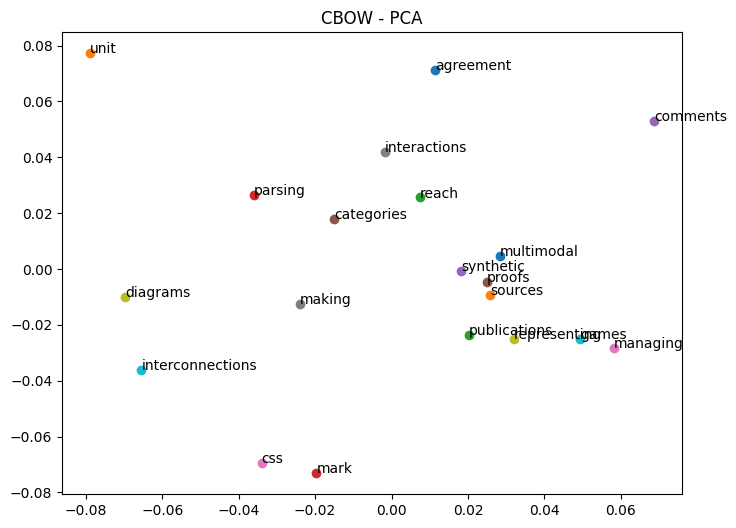

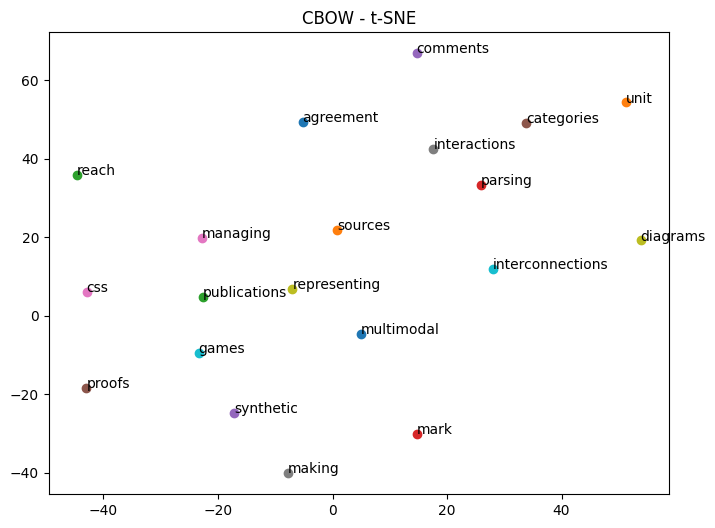

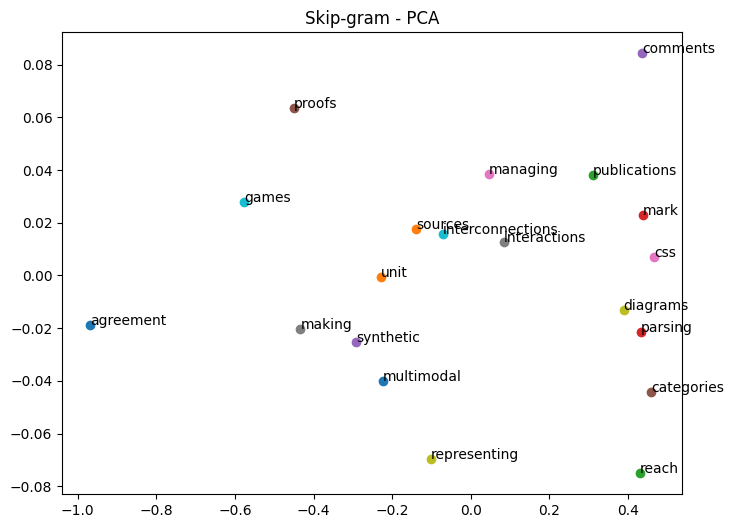

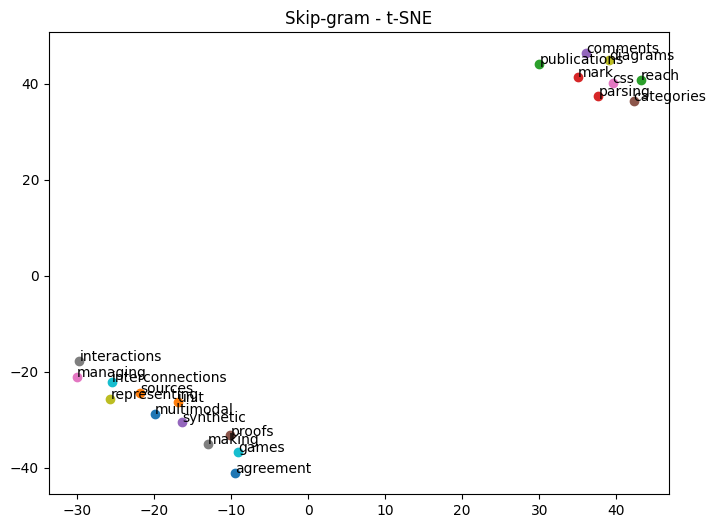

✅ Done! Images saved.


In [43]:
# ============================================================
# TASK-4: VISUALIZATION (ROBUST VERSION)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ------------------------------------------------------------
# 1. AUTO SELECT VALID WORDS (IMPORTANT FIX)
# ------------------------------------------------------------

# Ensure word2idx exists before using it
if 'word2idx' in globals():
    # pick top 20 words from vocab
    selected_words = list(word2idx.keys())[:20]

    print("Words used for visualization:")
    print(selected_words)

    # ------------------------------------------------------------
    # 2. GET VECTORS (SAFE)
    # ------------------------------------------------------------

    def get_vectors(words, W, word2idx):
        vectors = []
        labels = []
        for w in words:
            if w in word2idx:
                vectors.append(W[word2idx[w]])
                labels.append(w)
        return np.array(vectors), labels

    # ------------------------------------------------------------
    # 3. PCA FUNCTION
    # ------------------------------------------------------------

    def plot_pca(W, word2idx, title, filename):
        vectors, labels = get_vectors(selected_words, W, word2idx)
        if len(vectors) == 0:
            print("❌ No vectors found")
            return
        pca = PCA(n_components=2)
        reduced = pca.fit_transform(vectors)
        plt.figure(figsize=(8,6))
        for i, word in enumerate(labels):
            plt.scatter(reduced[i][0], reduced[i][1])
            plt.text(reduced[i][0], reduced[i][1], word)
        plt.title(title)
        plt.savefig(filename)
        plt.show()

    # ------------------------------------------------------------
    # 4. TSNE FUNCTION
    # ------------------------------------------------------------

    def plot_tsne(W, word2idx, title, filename):
        vectors, labels = get_vectors(selected_words, W, word2idx)
        if len(vectors) == 0:
            print("❌ No vectors found")
            return
        tsne = TSNE(n_components=2, perplexity=5, random_state=42)
        reduced = tsne.fit_transform(vectors)
        plt.figure(figsize=(8,6))
        for i, word in enumerate(labels):
            plt.scatter(reduced[i][0], reduced[i][1])
            plt.text(reduced[i][0], reduced[i][1], word)
        plt.title(title)
        plt.savefig(filename)
        plt.show()

    # ------------------------------------------------------------
    # 5. RUN (FIXED VARIABLE NAMES)
    # ------------------------------------------------------------

    if 'W_in_cbow' in globals() and 'W_in_sg' in globals():
        print("CBOW shape:", np.array(W_in_cbow).shape)
        print("Skip-gram shape:", np.array(W_in_sg).shape)

        # CBOW
        plot_pca(W_in_cbow, word2idx, "CBOW - PCA", "cbow_pca.png")
        plot_tsne(W_in_cbow, word2idx, "CBOW - t-SNE", "cbow_tsne.png")

        # Skip-gram
        plot_pca(W_in_sg, word2idx, "Skip-gram - PCA", "skipgram_pca.png")
        plot_tsne(W_in_sg, word2idx, "Skip-gram - t-SNE", "skipgram_tsne.png")

        print("✅ Done! Images saved.")
    else:
        print("❌ Training weights (W_in_cbow/W_in_sg) not found. Please run the training cell.")
else:
    print("❌ word2idx not defined. Please run the vocabulary building cell first.")